In [1]:
import cv2
import numpy as np
import os
import random
from scipy.signal import wiener
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time

In [2]:
dataset_folder = '/kaggle/input/handsign/RealvsForg'
total_classes = 0
total_images = 0  # Initialize a variable to store total images

for class_folder in os.listdir(dataset_folder):
  class_folder_path = os.path.join(dataset_folder, class_folder)
  if os.path.isdir(class_folder_path):
    total_classes += 1
    images = os.listdir(class_folder_path)
    num_images = len(images)
    print(f"Class: {class_folder}, Number of Images: {num_images}")
    total_images += num_images  # Add current class image count to total

print(f"Total number of classes: {total_classes}")
print(f"Total number of images: {total_images}")

Class: real, Number of Images: 1712
Class: forg, Number of Images: 1759
Total number of classes: 2
Total number of images: 3471


In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from transformers import AutoTokenizer , SwinForImageClassification,ViTForImageClassification
from torchvision import models,transforms, datasets
import torch.optim as optim
import cv2
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from torch.optim import lr_scheduler
from torch.optim import AdamW
import torch.optim as optim
import timm

In [4]:
train_dir =  '/kaggle/input/handsign/RealvsForg'
num_classes = total_classes
image_shape = (224, 224)
batch_size = 16
num_epochs = 10

In [5]:
class MakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.data = self.make_dataset()

    def make_dataset(self):
        images = []
        for cls in self.classes:
            cls_folder = os.path.join(self.root_dir, cls)
            for img_name in os.listdir(cls_folder):
                img_path = os.path.join(cls_folder, img_name)
                item = (img_path, self.class_to_idx[cls])
                images.append(item)
        return images

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
transform = transforms.Compose([
    transforms.Resize(image_shape),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [7]:
dataset = MakeDataset(train_dir, transform=transform)

In [8]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Training Samples:


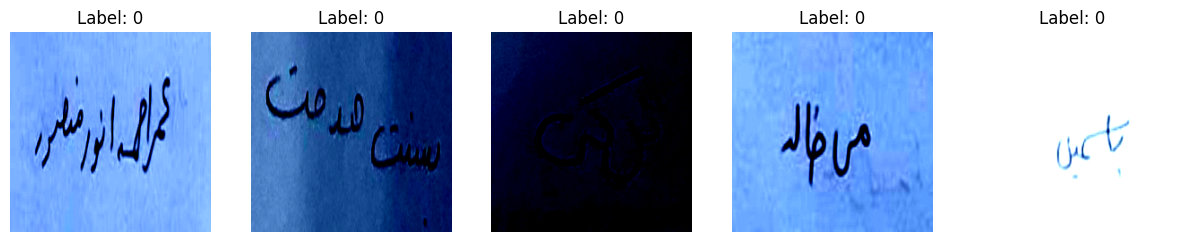

Validation Samples:


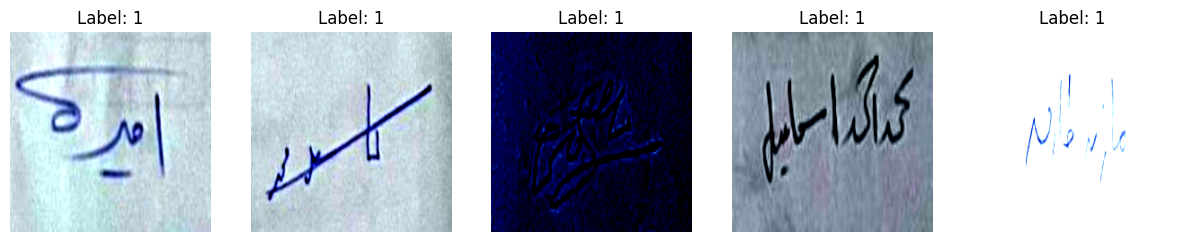

Testing Samples:


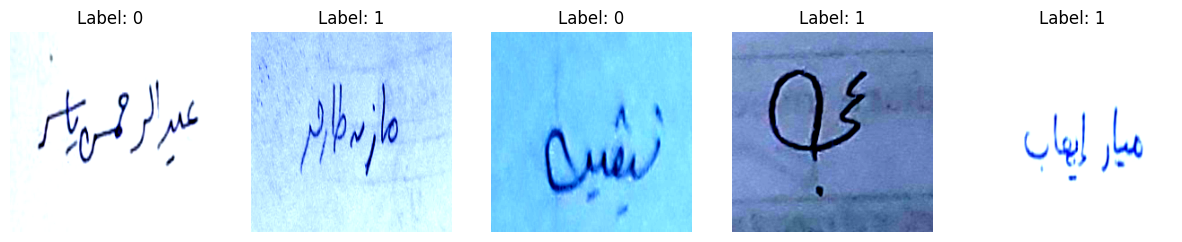

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Define a function to visualize images from a DataLoader
def visualize(loader, num_samples=5):
    # Iterate through the DataLoader to get a batch of data
    for batch_idx, (images, labels) in enumerate(loader):
        # Plot the images
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
        for i in range(num_samples):
            ax = axes[i]
            ax.imshow(np.transpose(images[i], (1, 2, 0)))
            ax.set_title(f"Label: {labels[i]}")
            ax.axis('off')
        plt.show()
        break  # Stop after displaying the first batch

# Visualize samples from the training loader
print("Training Samples:")
visualize(train_loader)

# Visualize samples from the validation loader
print("Validation Samples:")
visualize(val_loader)

print("Testing Samples:")
visualize(test_loader)

# Resnet50 + Deit


In [11]:
class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super(HybridModel, self).__init__()
        self.resnet = models.resnet50(weights='IMAGENET1K_V1')
        resnet_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # Remove the final fully connected layer

        self.transformer = timm.create_model('deit_base_patch16_224', pretrained=True)
        transformer_features = self.transformer.head.in_features
        self.transformer.head = nn.Identity()  # Remove the final classification head

        self.fc = nn.Linear(resnet_features + transformer_features, num_classes)

    def forward(self, x):
        resnet_features = self.resnet(x)
        transformer_features = self.transformer(x)
        combined_features = torch.cat((resnet_features, transformer_features), dim=1)
        x = self.fc(combined_features)
        return x

In [12]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
model = HybridModel(num_classes)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s]


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [15]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
predictions = []
targets = []
best_acc = 0.0

In [16]:
model = model.to(device)

In [17]:
start_time = time.time()

In [18]:
patience = 5  # Number of epochs with no improvement after which training will be stopped
counter = 0  # Counter for epochs with no improvement
best_val_loss = float('inf')  # Initialize best validation loss with infinity

# Training loop with early stopping
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        if -1 in labels:
            continue  # Skip the batch if it contains dummy labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted_train = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item()

        # Print training loss and accuracy every 100 batches
        if i % 100 == 99:
            print(f'Epoch {epoch + 1}/{num_epochs}, Batch {i + 1}/{len(train_loader)}, '
                  f'Training Loss: {running_loss / 100}, Training Accuracy: {100 * correct_train / total_train}%')

    # Calculate training accuracy after the epoch
    training_accuracy = correct_train / total_train

    # Validation
    model.eval()
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if -1 in labels:
                continue  # Skip the batch if it contains dummy labels

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, predicted_val = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted_val == labels).sum().item()

    # Calculate validation accuracy after the epoch
    validation_accuracy = correct_val / total_val
    average_val_loss = val_running_loss / len(val_loader)

    print(f'Epoch {epoch + 1}/{num_epochs}, '
          f'Training Loss: {running_loss / len(train_loader)}, '
          f'Training Accuracy: {100 * training_accuracy}%, '
          f'Validation Loss: {average_val_loss}, '
          f'Validation Accuracy: {100 * validation_accuracy}%')

    # Append training and validation metrics for plotting
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(training_accuracy)
    val_losses.append(average_val_loss)
    val_accuracies.append(validation_accuracy)

    # Early stopping logic
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        counter = 0
        torch.save(model.state_dict(), 'resnetvitbest_model.pth')  # Save the best model
    else:
        counter += 1
        print(f'No improvement in validation loss for {counter} epoch(s)')
        if counter >= patience:
            print('Early stopping triggered')
            break

    scheduler.step()

Epoch 1/10, Batch 100/174, Training Loss: 0.2525290295481682, Training Accuracy: 88.625%
Epoch 1/10, Training Loss: 0.2243355640756159, Training Accuracy: 90.67002881844381%, Validation Loss: 0.07768059250983325, Validation Accuracy: 98.55907780979827%
Epoch 2/10, Batch 100/174, Training Loss: 0.09519816123647615, Training Accuracy: 97.0%
Epoch 2/10, Training Loss: 0.08695504084649634, Training Accuracy: 97.19020172910663%, Validation Loss: 0.10092769169502637, Validation Accuracy: 96.82997118155619%
No improvement in validation loss for 1 epoch(s)
Epoch 3/10, Batch 100/174, Training Loss: 0.06050007660407573, Training Accuracy: 97.75%
Epoch 3/10, Training Loss: 0.0752489071716715, Training Accuracy: 97.47838616714697%, Validation Loss: 0.021300398480062457, Validation Accuracy: 99.13544668587896%
Epoch 4/10, Batch 100/174, Training Loss: 0.04119683733850252, Training Accuracy: 98.6875%
Epoch 4/10, Training Loss: 0.03643158945036201, Training Accuracy: 98.95533141210375%, Validation Lo

In [19]:
end_time = time.time()

duration_seconds = end_time - start_time
duration_minutes = duration_seconds / 60

print("Training duration: {:.2f} minutes".format(duration_minutes))

Training duration: 22.84 minutes


In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
def evaluate_model(model, test_loader, device):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    test_accuracy = correct / total
    

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Precision, Recall, F1 Score
    precision = precision_score(all_labels, all_predictions, average='weighted')
    recall = recall_score(all_labels, all_predictions, average='weighted')
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    
    
    print(f'Test Accuracy: {100 * test_accuracy}%')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1}')

    return test_accuracy, precision, recall, f1

In [22]:
model.load_state_dict(torch.load('/kaggle/working/resnetvitbest_model.pth'))

<All keys matched successfully>

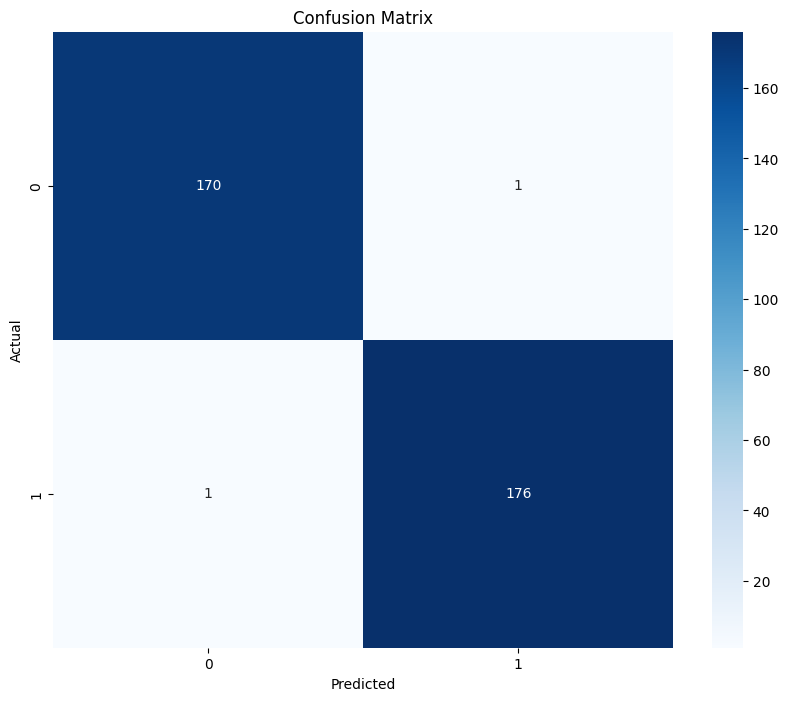

Test Accuracy: 99.42528735632183%
Precision: 0.9942528735632183
Recall: 0.9942528735632183
F1 Score: 0.9942528735632183


In [23]:
test_accuracy, precision, recall, f1 = evaluate_model(model, test_loader, device)

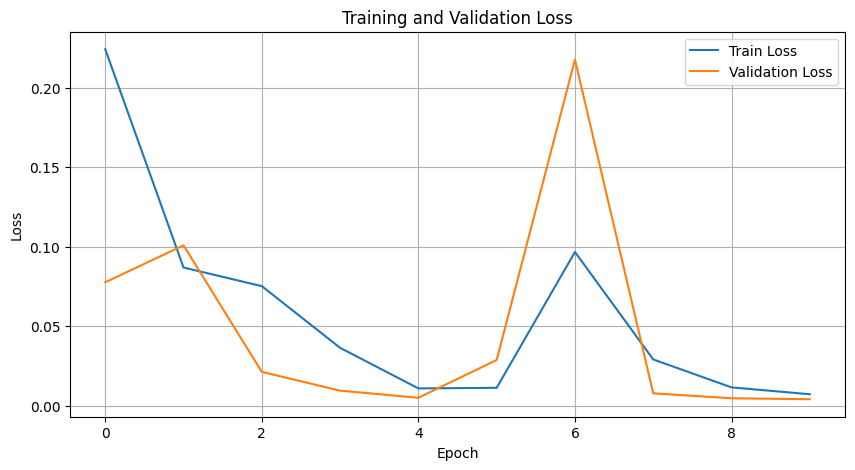

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

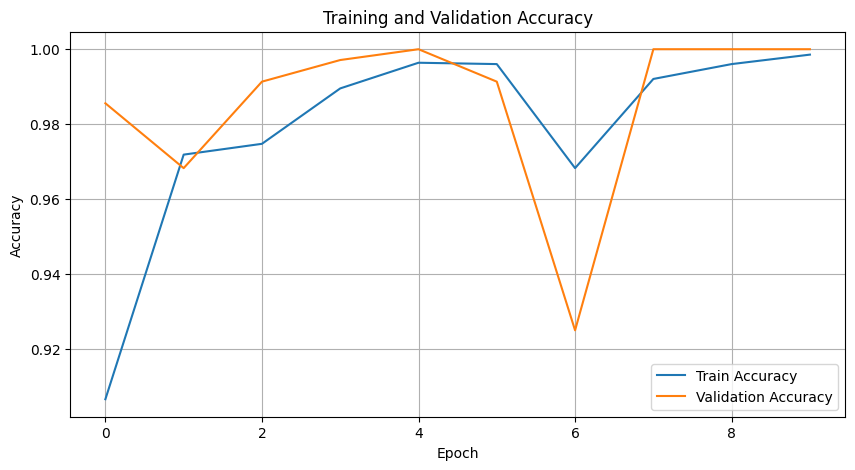

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Mobile+Vit

In [26]:
class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super(HybridModel, self).__init__()
        self.mobilenet = models.mobilenet_v2(weights='IMAGENET1K_V1')
        mobilenet_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Identity()  # Remove the final fully connected layer

        self.transformer = timm.create_model('deit_base_patch16_224', pretrained=True)
        transformer_features = self.transformer.head.in_features
        self.transformer.head = nn.Identity()  # Remove the final classification head

        self.fc = nn.Linear(mobilenet_features + transformer_features, num_classes)

    def forward(self, x):
        mobilenet_features = self.mobilenet(x)
        transformer_features = self.transformer(x)
        combined_features = torch.cat((mobilenet_features, transformer_features), dim=1)
        x = self.fc(combined_features)
        return x

In [27]:
import gc
def free_cuda_memory(model, optimizer):
    print("Freeing CUDA memory...")
    
    # Delete the model and optimizer
    del model
    del optimizer
    
    # Call torch.cuda.empty_cache() to release unoccupied cached memory
    torch.cuda.empty_cache()
    
    # Collect garbage to clean up circular references
    gc.collect()
    
    # Again, call empty_cache to ensure the memory is freed
    torch.cuda.empty_cache()
    print("Done")

In [28]:
free_cuda_memory(model, optimizer)

Freeing CUDA memory...
Done


In [29]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [30]:
model = HybridModel(num_classes)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 72.7MB/s]


In [31]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [32]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
predictions = []
targets = []
best_acc = 0.0

In [33]:
model = model.to(device)

In [34]:
start_time = time.time()

In [35]:
patience = 5  # Number of epochs with no improvement after which training will be stopped
counter = 0  # Counter for epochs with no improvement
best_val_loss = float('inf')  # Initialize best validation loss with infinity

# Training loop with early stopping
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        if -1 in labels:
            continue  # Skip the batch if it contains dummy labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted_train = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item()

        # Print training loss and accuracy every 100 batches
        if i % 100 == 99:
            print(f'Epoch {epoch + 1}/{num_epochs}, Batch {i + 1}/{len(train_loader)}, '
                  f'Training Loss: {running_loss / 100}, Training Accuracy: {100 * correct_train / total_train}%')

    # Calculate training accuracy after the epoch
    training_accuracy = correct_train / total_train

    # Validation
    model.eval()
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if -1 in labels:
                continue  # Skip the batch if it contains dummy labels

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, predicted_val = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted_val == labels).sum().item()

    # Calculate validation accuracy after the epoch
    validation_accuracy = correct_val / total_val
    average_val_loss = val_running_loss / len(val_loader)

    print(f'Epoch {epoch + 1}/{num_epochs}, '
          f'Training Loss: {running_loss / len(train_loader)}, '
          f'Training Accuracy: {100 * training_accuracy}%, '
          f'Validation Loss: {average_val_loss}, '
          f'Validation Accuracy: {100 * validation_accuracy}%')

    # Append training and validation metrics for plotting
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(training_accuracy)
    val_losses.append(average_val_loss)
    val_accuracies.append(validation_accuracy)

    # Early stopping logic
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        counter = 0
        torch.save(model.state_dict(), 'mobilevitbest_model.pth')  # Save the best model
    else:
        counter += 1
        print(f'No improvement in validation loss for {counter} epoch(s)')
        if counter >= patience:
            print('Early stopping triggered')
            break

    scheduler.step()

Epoch 1/10, Batch 100/174, Training Loss: 0.28015330467373134, Training Accuracy: 87.6875%
Epoch 1/10, Training Loss: 0.21254287762085683, Training Accuracy: 90.63400576368876%, Validation Loss: 0.05549517756497318, Validation Accuracy: 98.84726224783861%
Epoch 2/10, Batch 100/174, Training Loss: 0.060526861391263086, Training Accuracy: 97.875%
Epoch 2/10, Training Loss: 0.07304518206657884, Training Accuracy: 97.40634005763688%, Validation Loss: 0.05047486746810715, Validation Accuracy: 97.98270893371757%
Epoch 3/10, Batch 100/174, Training Loss: 0.04722436097363243, Training Accuracy: 98.25%
Epoch 3/10, Training Loss: 0.0671965532620697, Training Accuracy: 97.62247838616715%, Validation Loss: 0.13815262080805207, Validation Accuracy: 95.38904899135446%
No improvement in validation loss for 1 epoch(s)
Epoch 4/10, Batch 100/174, Training Loss: 0.0585092671419261, Training Accuracy: 98.0625%
Epoch 4/10, Training Loss: 0.04688237015600851, Training Accuracy: 98.37896253602305%, Validatio

In [36]:
end_time = time.time()

duration_seconds = end_time - start_time
duration_minutes = duration_seconds / 60

print("Training duration: {:.2f} minutes".format(duration_minutes))

Training duration: 19.40 minutes


In [37]:
model.load_state_dict(torch.load('/kaggle/working/mobilevitbest_model.pth'))

<All keys matched successfully>

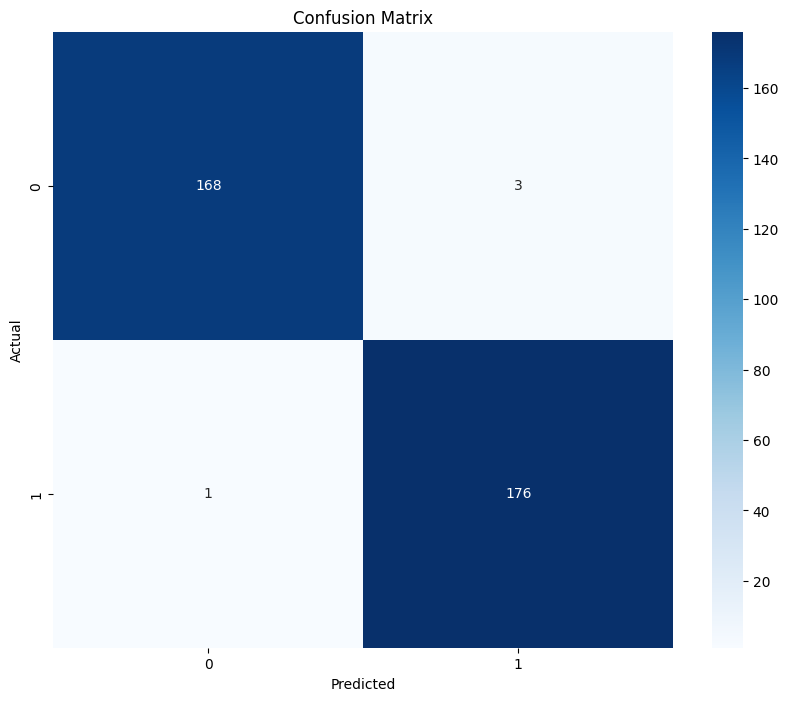

Test Accuracy: 98.85057471264368%
Precision: 0.9885680610159369
Recall: 0.9885057471264368
F1 Score: 0.9885042277275109


In [38]:
test_accuracy, precision, recall, f1 = evaluate_model(model, test_loader, device)

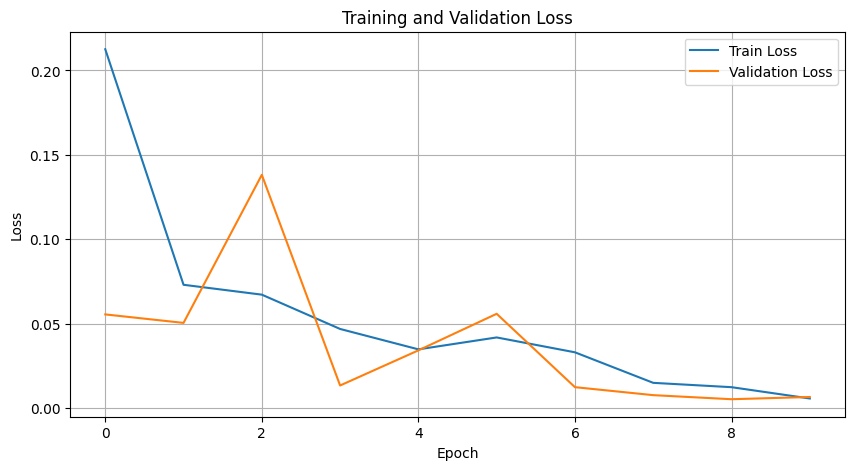

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

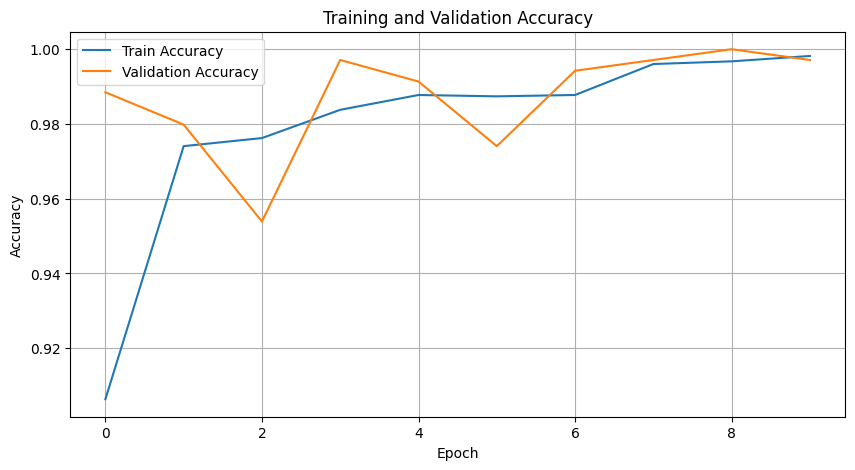

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# EFFB7 + VIT

In [41]:
class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super(HybridModel, self).__init__()
        self.efficientnet = models.efficientnet_b7(pretrained=True)
        efficientnet_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Identity()  # Remove the final fully connected layer

        self.transformer = timm.create_model('deit_base_patch16_224', pretrained=True)
        transformer_features = self.transformer.head.in_features
        self.transformer.head = nn.Identity()  # Remove the final classification head

        self.fc = nn.Linear(efficientnet_features + transformer_features, num_classes)

    def forward(self, x):
        efficientnet_features = self.efficientnet(x)
        transformer_features = self.transformer(x)
        combined_features = torch.cat((efficientnet_features, transformer_features), dim=1)
        x = self.fc(combined_features)
        return x

In [42]:
free_cuda_memory(model, optimizer)

Freeing CUDA memory...
Done


In [43]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [44]:
model = HybridModel(num_classes)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth
100%|██████████| 255M/255M [00:01<00:00, 137MB/s]


In [45]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [46]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
predictions = []
targets = []
best_acc = 0.0

In [47]:
model = model.to(device)

In [48]:
start_time = time.time()

In [49]:
patience = 5  # Number of epochs with no improvement after which training will be stopped
counter = 0  # Counter for epochs with no improvement
best_val_loss = float('inf')  # Initialize best validation loss with infinity

# Training loop with early stopping
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        if -1 in labels:
            continue  # Skip the batch if it contains dummy labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted_train = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item()

        # Print training loss and accuracy every 100 batches
        if i % 100 == 99:
            print(f'Epoch {epoch + 1}/{num_epochs}, Batch {i + 1}/{len(train_loader)}, '
                  f'Training Loss: {running_loss / 100}, Training Accuracy: {100 * correct_train / total_train}%')

    # Calculate training accuracy after the epoch
    training_accuracy = correct_train / total_train

    # Validation
    model.eval()
    correct_val = 0
    total_val = 0
    val_running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if -1 in labels:
                continue  # Skip the batch if it contains dummy labels

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, predicted_val = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted_val == labels).sum().item()

    # Calculate validation accuracy after the epoch
    validation_accuracy = correct_val / total_val
    average_val_loss = val_running_loss / len(val_loader)

    print(f'Epoch {epoch + 1}/{num_epochs}, '
          f'Training Loss: {running_loss / len(train_loader)}, '
          f'Training Accuracy: {100 * training_accuracy}%, '
          f'Validation Loss: {average_val_loss}, '
          f'Validation Accuracy: {100 * validation_accuracy}%')

    # Append training and validation metrics for plotting
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(training_accuracy)
    val_losses.append(average_val_loss)
    val_accuracies.append(validation_accuracy)

    # Early stopping logic
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        counter = 0
        torch.save(model.state_dict(), 'effvitbest_model.pth')  # Save the best model
    else:
        counter += 1
        print(f'No improvement in validation loss for {counter} epoch(s)')
        if counter >= patience:
            print('Early stopping triggered')
            break

    scheduler.step()

Epoch 1/10, Batch 100/174, Training Loss: 0.2675173116475344, Training Accuracy: 88.3125%
Epoch 1/10, Training Loss: 0.21675062571363202, Training Accuracy: 90.74207492795388%, Validation Loss: 0.08799014121971348, Validation Accuracy: 98.55907780979827%
Epoch 2/10, Batch 100/174, Training Loss: 0.04977953926834743, Training Accuracy: 98.375%
Epoch 2/10, Training Loss: 0.053888569196589804, Training Accuracy: 98.23487031700289%, Validation Loss: 0.020586905601455575, Validation Accuracy: 99.13544668587896%
Epoch 3/10, Batch 100/174, Training Loss: 0.044464845873299054, Training Accuracy: 98.5%
Epoch 3/10, Training Loss: 0.029573651570335015, Training Accuracy: 99.06340057636888%, Validation Loss: 0.01378628222433194, Validation Accuracy: 99.42363112391931%
Epoch 4/10, Batch 100/174, Training Loss: 0.025372174243530027, Training Accuracy: 99.1875%
Epoch 4/10, Training Loss: 0.01915792687291339, Training Accuracy: 99.31556195965418%, Validation Loss: 0.007420890461865135, Validation Accu

In [50]:
end_time = time.time()

duration_seconds = end_time - start_time
duration_minutes = duration_seconds / 60

print("Training duration: {:.2f} minutes".format(duration_minutes))

Training duration: 31.73 minutes


In [51]:
model.load_state_dict(torch.load('/kaggle/working/effvitbest_model.pth'))

<All keys matched successfully>

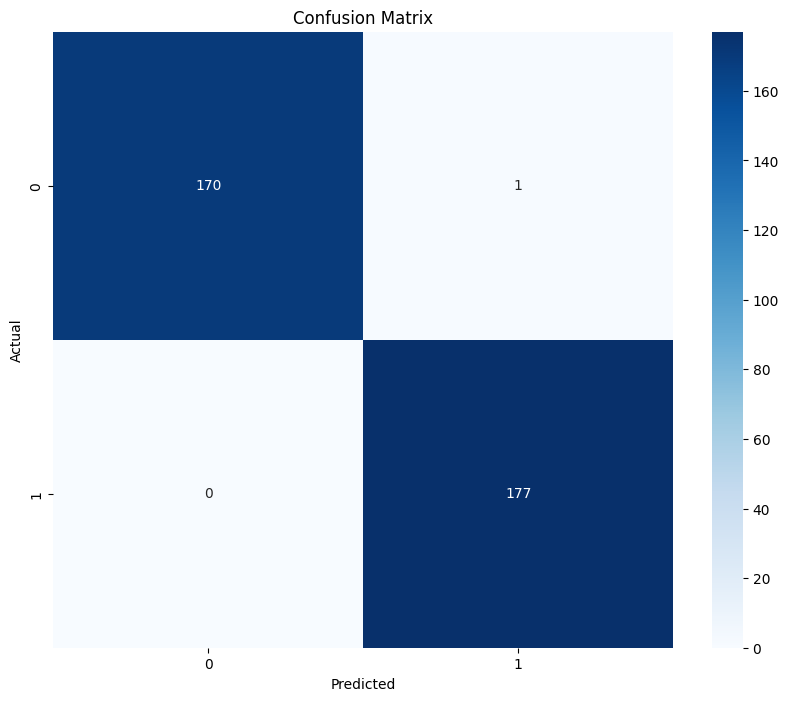

Test Accuracy: 99.71264367816092%
Precision: 0.9971425803951958
Recall: 0.9971264367816092
F1 Score: 0.9971262706179437


In [52]:
test_accuracy, precision, recall, f1 = evaluate_model(model, test_loader, device)

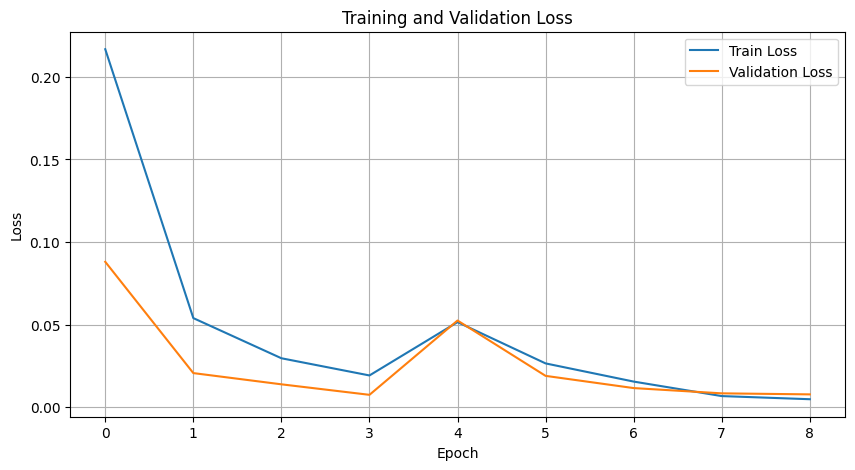

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

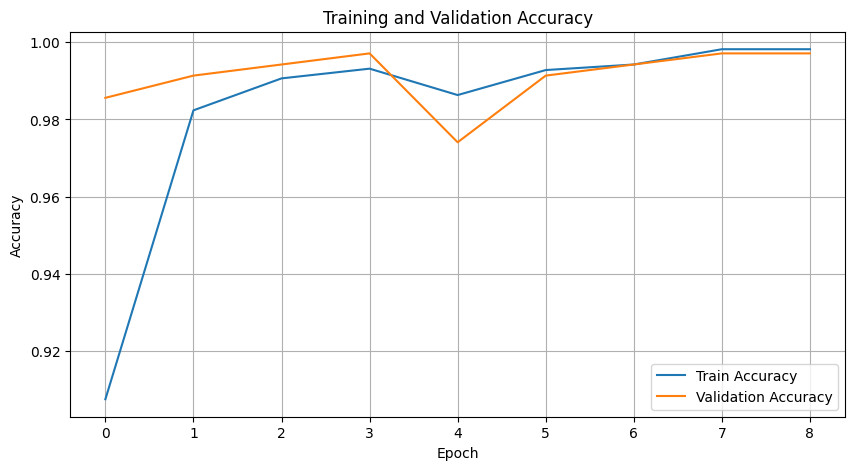

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()